# GP Kernels 

This notebook studies the effect of the choice of Kernels in the modeling efficiency. 

## Kernels 

Given a function $f: \mathbb R^n \rightarrow \mathbb R$, the GP Kernel $k(-, -): \mathbb R^n \times \mathbb R^n \rightarrow \mathbb R$ vaguely aims to encode how outputs $f(x), f(y)$ (co)-vary with respect to $(x, y)$.

/home/rraanto/.local/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


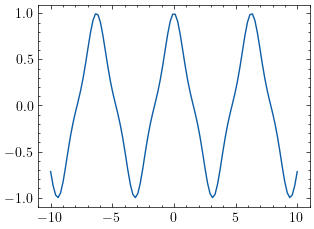

In [1]:
import numpy as np 
import gpytorch as gp 
import torch 

from matplotlib import pyplot as plt 
import scienceplots 
plt.style.use("science") 
from exact_gp_model import Surrogate 

def f(x): 
    return torch.cos(torch.sin(x)) * torch.cos(x) 

bounds = (-10, 10)

plt.figure() 
plt.plot(torch.linspace(*bounds, 100), f(torch.linspace(*bounds, 100)))

## Constructing custom kernel with GPytorch 

The base class `gpytorch.kernels.Kernel` gives the template for creating kernels that can be used with GP models. It contains the method `Kernel.forward` computing $k(X, Y)$ from two input tensors $X, Y$ and a boolean `diag` defaulting to `False`, which the caller sets to `True` if only the diagonal elements $k(x_1, y_1), \dots, k(x_i, y_i), \dots$ need be returned. 

In [36]:
## Constructing the kernel for a model 